In [71]:
#importing the dependencies 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split 
from sklearn import metrics
from xgboost import XGBRegressor 

In [31]:
#data collection and preprocessing 
dataset=pd.read_csv('big_mart_data.csv')

In [32]:
dataset.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [33]:
#let's see the number of data-points and number of features 
dataset.shape

(8523, 12)

In [34]:
#some information about the dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


**Categorical values:**


-Item_identifier


-Item_Fat_Content


-Item_Type


-Outlet_Identifier


-Outlet_Size 


-Outlet_Location_Type


-Outlet_Type 


In [35]:
#checking the missing values 
dataset.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

handeling the missing values

we will be using here 

Mean-->average value 

Mode-->repeated value 


In [36]:
#mean value of "item_weight" column
dataset['Item_Weight'].mean()

np.float64(12.857645184135976)

In [37]:
#filling the missing values in "item_weight" column
dataset['Item_Weight'].fillna(dataset['Item_Weight'].mean(),inplace=True)

C:\Users\manoj\AppData\Local\Temp\ipykernel_14844\2547417920.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Item_Weight'].fillna(dataset['Item_Weight'].mean(),inplace=True)


In [38]:
dataset.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [39]:
#mode vlaue of the "outlet_size" column
dataset['Outlet_Size'].mode()

0    Medium
Name: Outlet_Size, dtype: object

In [40]:
#replacing the missing value with the mode value in "outlet_size" column
mode_of_outlet_size=dataset.pivot_table(values='Outlet_Size',columns='Outlet_Type',aggfunc=(lambda x:x.mode()[0]))

In [41]:
mode_of_outlet_size

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [42]:
#let's check the missing values
missing_values=dataset["Outlet_Size"].isnull()

In [43]:
print(missing_values)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool


In [44]:
dataset.loc[missing_values,'Outlet_Size']=dataset.loc[missing_values,'Outlet_Type'].apply( lambda x:mode_of_outlet_size[x])

In [45]:
dataset.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [46]:
#data analysis
dataset.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


**Numerical Measures**

In [47]:
sns.set()

C:\Users\manoj\AppData\Local\Temp\ipykernel_14844\2915278817.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Item_Weight'])


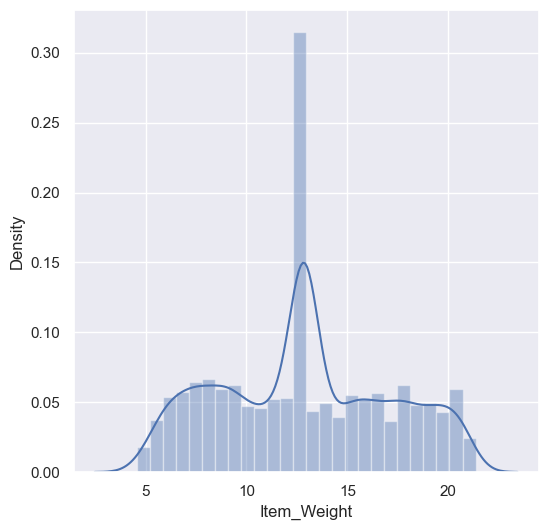

In [48]:
#ltem weight distribution 
plt.figure(figsize=(6,6))
sns.distplot(dataset['Item_Weight'])
plt.show()

C:\Users\manoj\AppData\Local\Temp\ipykernel_14844\3219225916.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Item_Visibility'])


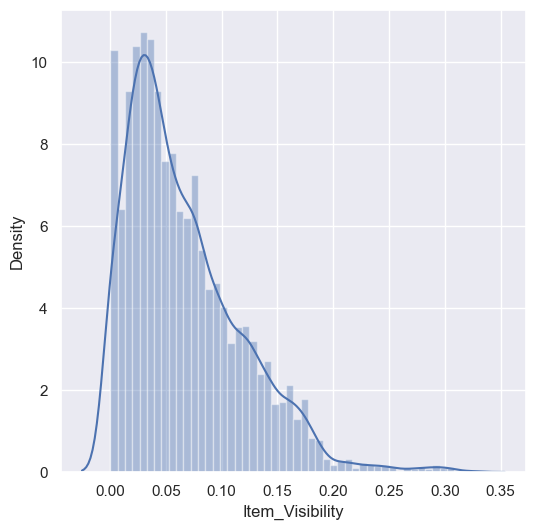

In [49]:
#ltem weight distribution 
plt.figure(figsize=(6,6))
sns.distplot(dataset['Item_Visibility'])
plt.show()

C:\Users\manoj\AppData\Local\Temp\ipykernel_14844\1067664707.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Item_MRP'])


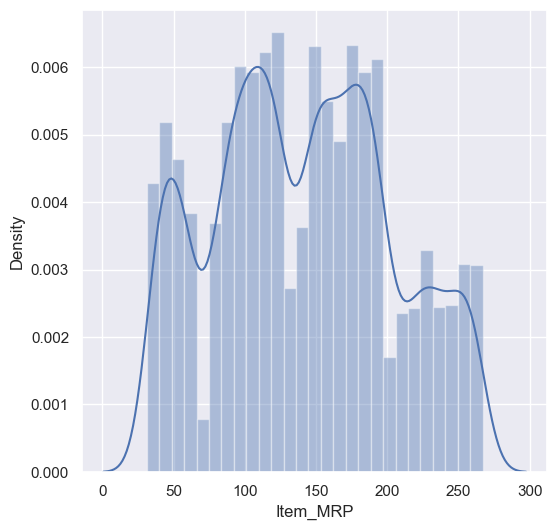

In [50]:
#ltem weight distribution 
plt.figure(figsize=(6,6))
sns.distplot(dataset['Item_MRP'])
plt.show()

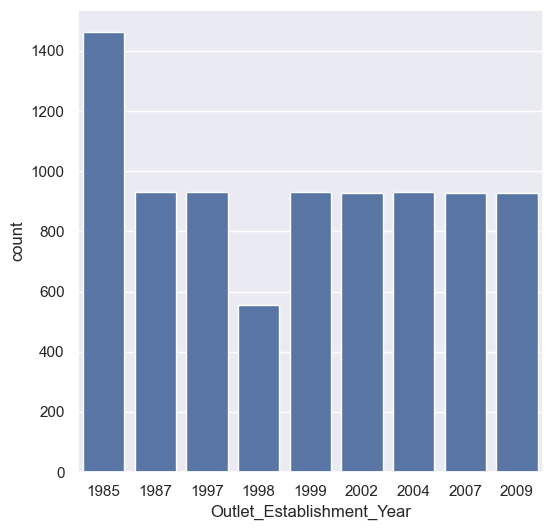

In [51]:
#ltem weight distribution 
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Establishment_Year',data=dataset)
plt.show()

C:\Users\manoj\AppData\Local\Temp\ipykernel_14844\2087282051.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Item_Outlet_Sales'])


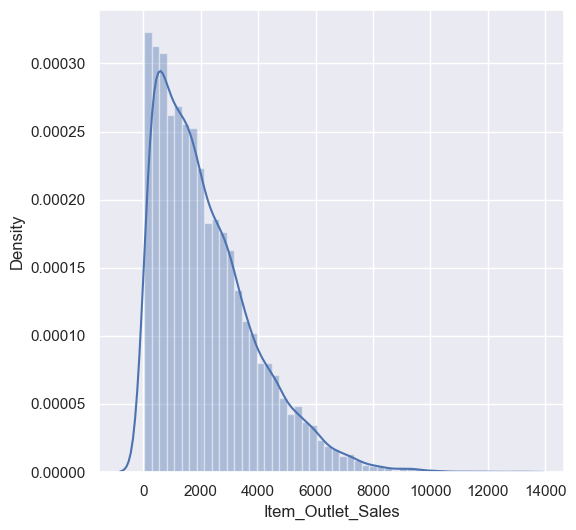

In [52]:
#ltem weight distribution 
plt.figure(figsize=(6,6))
sns.distplot(dataset['Item_Outlet_Sales'])
plt.show()

**Categorical Measures**

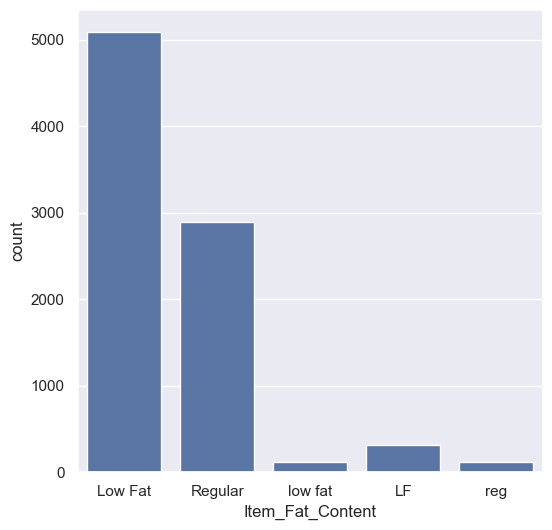

In [53]:
#item fat contains
plt.figure(figsize=(6,6))
sns.countplot(x='Item_Fat_Content',data=dataset)
plt.show()

In [54]:
#so we can see the data is not cleaned we have to clean the data as well cuz low fat lf are same and the regular and rg are same 

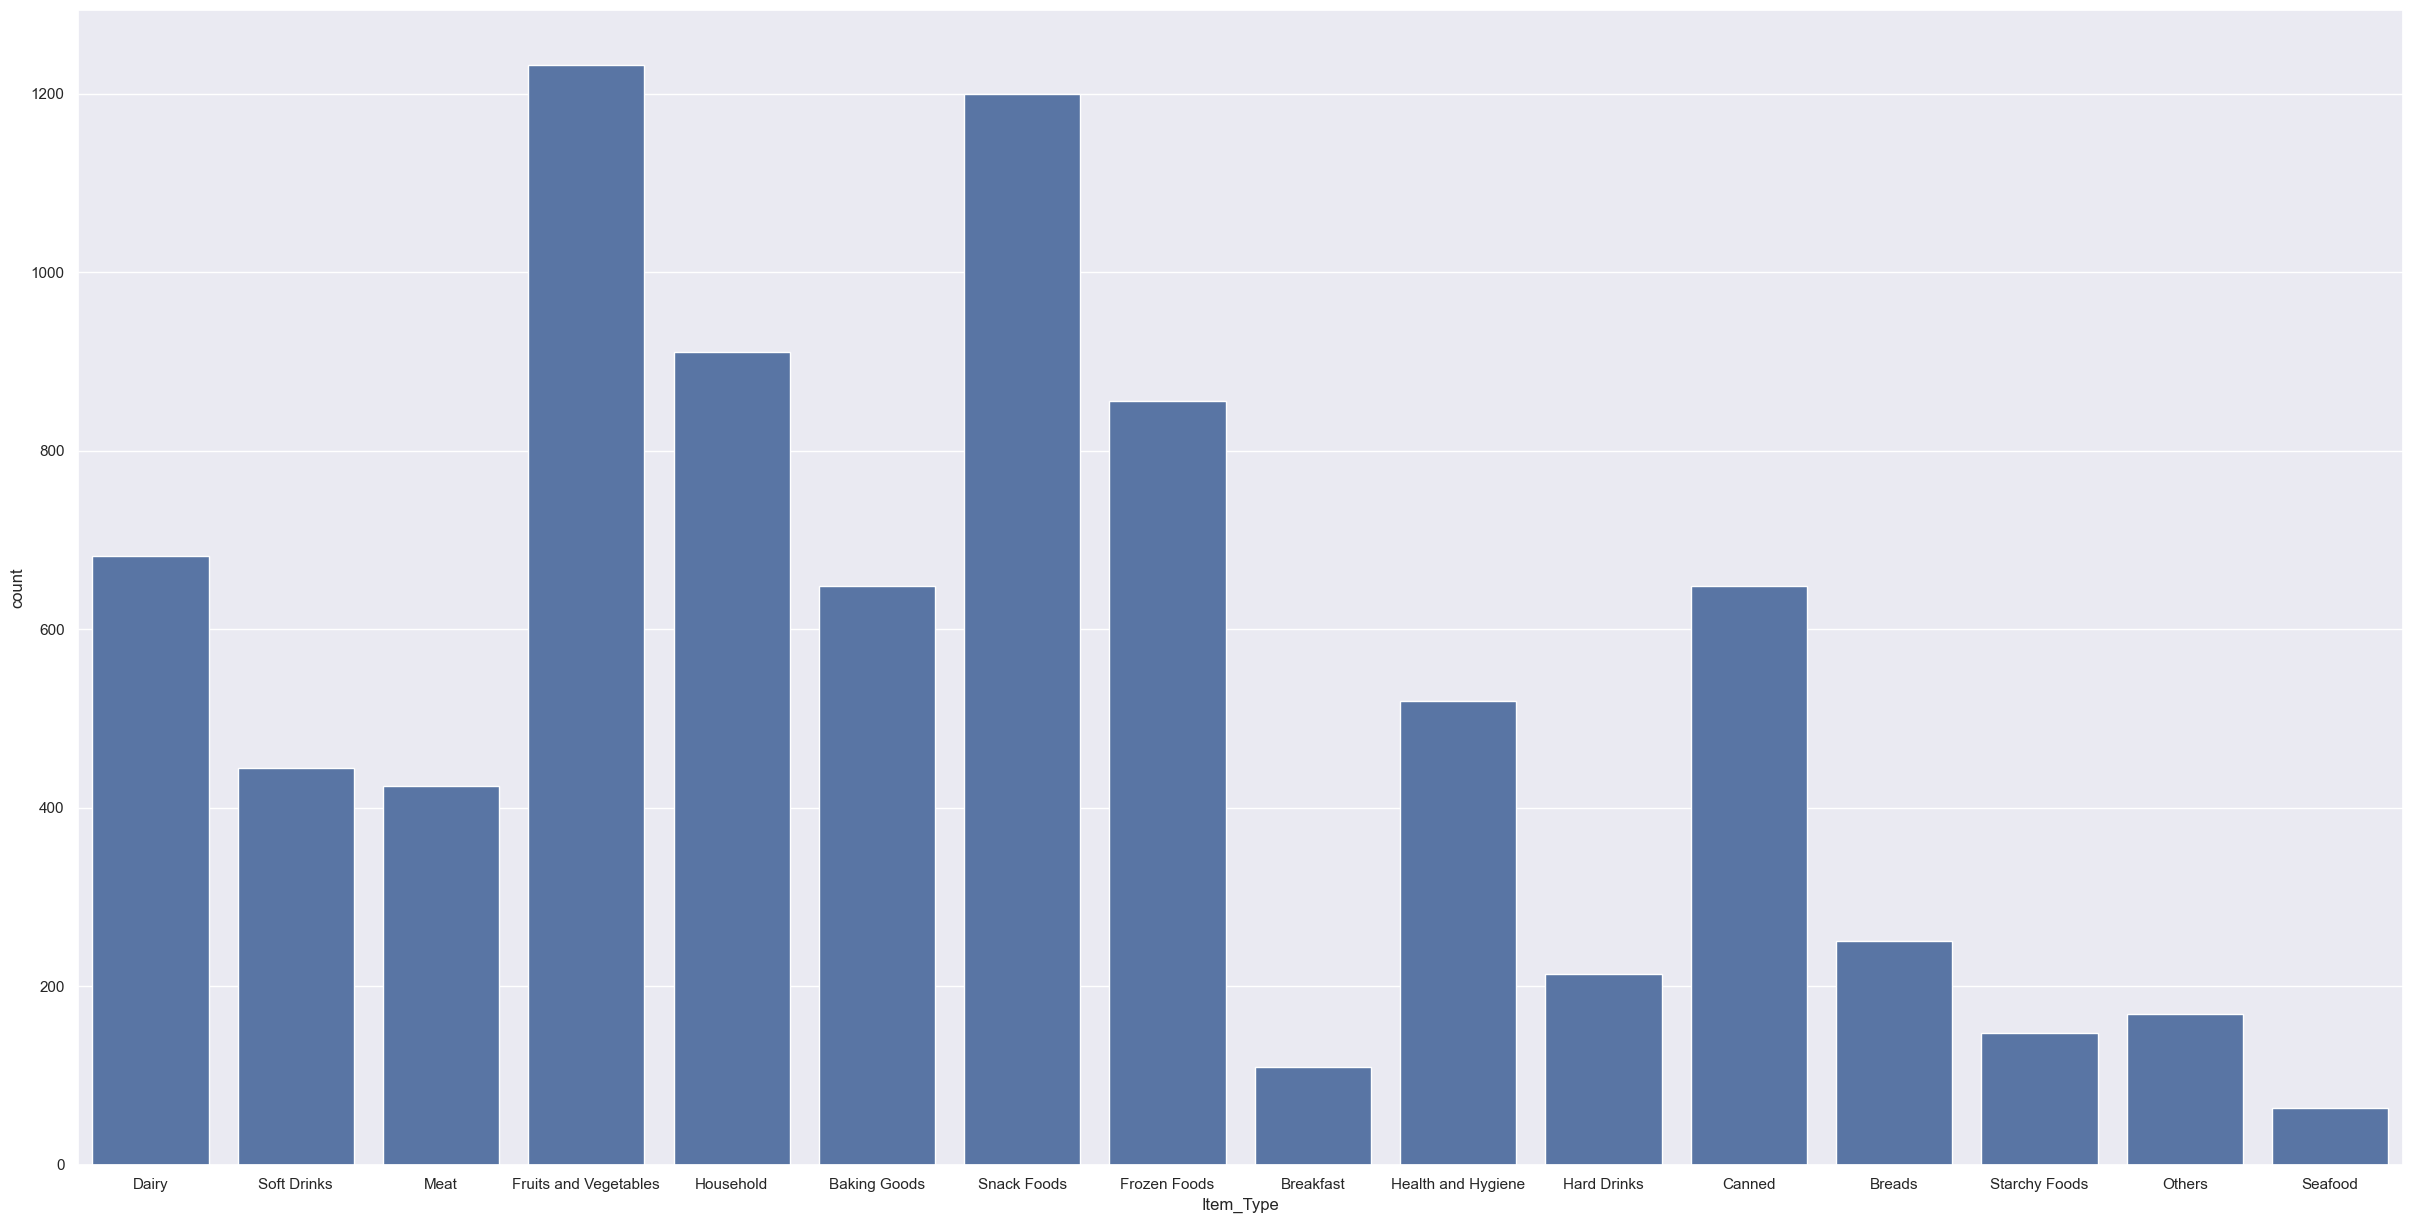

In [55]:
#item type
plt.figure(figsize=(30,15))
sns.countplot(x='Item_Type',data=dataset)
plt.show()

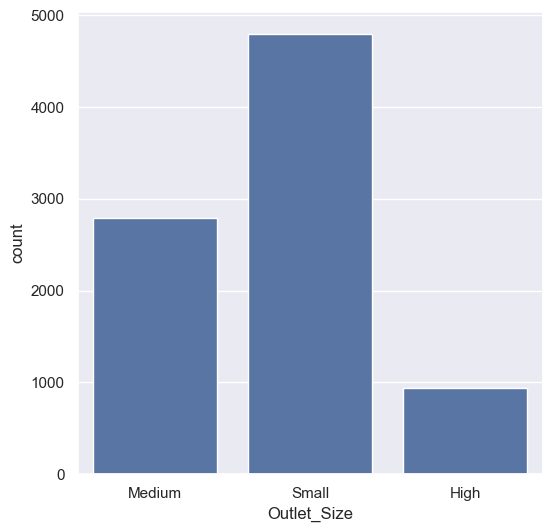

In [56]:
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Size',data=dataset)
plt.show()

**let's first convert that low fat lf and regural and rg data into one** 

In [62]:
dataset.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [66]:
dataset['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [67]:
dataset.replace({'Item_Fat_Content':{'low fat':'Low Fat','LF':'Low Fat','reg':'Regular'}},inplace=True)

In [68]:
dataset['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

## Label Encoding 

In [72]:
encoder=LabelEncoder()

In [75]:
dataset['Item_Identifier']= encoder.fit_transform(dataset['Item_Identifier'])
dataset['Item_Fat_Content']= encoder.fit_transform(dataset['Item_Fat_Content'])
dataset['Item_Type']= encoder.fit_transform(dataset['Item_Type'])
dataset['Outlet_Identifier']= encoder.fit_transform(dataset['Outlet_Identifier'])
dataset['Outlet_Size']= encoder.fit_transform(dataset['Outlet_Size'])
dataset['Outlet_Location_Type']= encoder.fit_transform(dataset['Outlet_Location_Type'])
dataset['Outlet_Type']= encoder.fit_transform(dataset['Outlet_Type'])

In [76]:
dataset.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [77]:
#splitting the data in the form of x and y
x=dataset.drop(columns='Item_Outlet_Sales',axis=1)
y=dataset.Item_Outlet_Sales

In [78]:
print(x)

      Item_Identifier  Item_Weight  Item_Fat_Content  Item_Visibility  \
0                 156        9.300                 0         0.016047   
1                   8        5.920                 1         0.019278   
2                 662       17.500                 0         0.016760   
3                1121       19.200                 1         0.000000   
4                1297        8.930                 0         0.000000   
...               ...          ...               ...              ...   
8518              370        6.865                 0         0.056783   
8519              897        8.380                 1         0.046982   
8520             1357       10.600                 0         0.035186   
8521              681        7.210                 1         0.145221   
8522               50       14.800                 0         0.044878   

      Item_Type  Item_MRP  Outlet_Identifier  Outlet_Establishment_Year  \
0             4  249.8092                  9    

In [79]:
print(y)


0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64


In [81]:
#splittng the data into training and testing data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=3)

In [82]:
print(x.shape,x_train.shape,x_test.shape)

(8523, 11) (6818, 11) (1705, 11)


In [83]:
print(y.shape,y_train.shape,y_test.shape)

(8523,) (6818,) (1705,)


## Loading the model 

In [84]:
model=XGBRegressor()

In [85]:
model.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [86]:
#let's test it on the basis of r2score 
#on training and testing data
training_data_prediction=model.predict(x_train)

In [87]:
r2_train=metrics.r2_score(y_train,training_data_prediction)

In [88]:
print(f"The r2 score for training is :{r2_train}")

The r2 score for training is :0.8726246624551304


In [89]:
#let's test it on the testing data
testing_data_prediction=model.predict(x_test)

In [90]:
r2_test=metrics.r2_score(y_test,testing_data_prediction)

In [91]:
print(f"The r2 score for testing is :{r2_test}")

The r2 score for testing is :0.547548231562019


the values are between 0 and 1 means the model is pretty accurate 